# `geom_gauge()`

`geom_gauge()` draws a semicircle gauge at a given (`x`, `y`) position.

It is useful for KPI indicators and dashboard-style summaries.

Important: `value` and `hole` are layer parameters (not mapped aesthetics),
so different gauge values are usually added as separate `geom_gauge()` layers.

In [1]:
from lets_plot import *


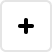
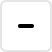
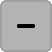
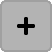
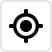
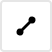
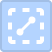
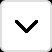
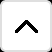
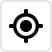
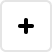
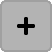
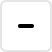
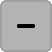
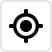
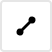
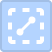
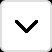
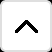
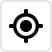

In [2]:
LetsPlot.setup_html()

## 1. Basic gauge

In [3]:
basic_df = {'x': [0], 'y': [0], 'label': ['72%']}

(
    ggplot(basic_df, aes('x', 'y'))
    + geom_gauge(value=0.72, hole=0.45, size=42, fill='#2E7D32', color='#FF0000', stroke=1.2)
    + geom_text(aes(label='label'), y=0.05, size=11, fontface='bold')
    + coord_fixed()
    + xlim(-1.1, 1.1)
    + ylim(-0.35, 1.05)
    + theme_void()
    + ggtitle('Simple KPI Gauge')
)

## 2. `value` controls the filled arc

In [9]:
def gauge_by_value(value, title, color):
    return (
        ggplot({'x': [0], 'y': [0]}, aes('x', 'y'))
        + geom_gauge(value=value, hole=0.5, size=24, fill=color, color='#2F3640', stroke=1.0)
        + coord_fixed()
        + xlim(-1.1, 1.1)
        + ylim(-0.35, 1.05)
        + theme_void()
        + ggtitle(title)
    )

gggrid([
    gauge_by_value(0.2, 'Low', '#D32F2F'), gauge_by_value(0.55, 'Medium', '#F9A825'), gauge_by_value(0.9, 'High', '#2E7D32')
])

## 3. Gauge shape: `hole` and `size`

In [14]:
def gauge_shape(hole, size, title):
    return (
        ggplot({'x': [0], 'y': [0]}, aes('x', 'y')) +
        geom_gauge(value=0.65, hole=hole, size=size, fill='#F57C00') +
        coord_fixed() +
        xlim(-1, 1) + ylim(-0.2, 1.0) +
        ggtitle(title) +
        theme_void() +
        theme(plot_title=element_text(hjust=0.5))
    )

gggrid([
    gauge_shape(hole=0.3, size=10, title='hole=0.3, size=20'),
    gauge_shape(hole=0.8, size=20, title='hole=0.8, size=20'),
    gauge_shape(hole=0.3, size=30, title='hole=0.3, size=30'),
    gauge_shape(hole=0.8, size=30, title='hole=0.8, size=30'),
], ncol=2)

## 4. KPI board with multiple gauges

In [6]:
kpi_data = [
    {'metric': 'Availability', 'x': 0.0, 'y': 0.0, 'value': 0.94, 'label': '94%', 'fill': '#2E7D32'},
    {'metric': 'Quality',      'x': 1.6, 'y': 0.0, 'value': 0.78, 'label': '78%', 'fill': '#F9A825'},
    {'metric': 'Delivery',     'x': 3.2, 'y': 0.0, 'value': 0.61, 'label': '61%', 'fill': '#EF6C00'},
]

kpi_data

[{'metric': 'Availability',
  'x': 0.0,
  'y': 0.0,
  'value': 0.94,
  'label': '94%',
  'fill': '#2E7D32'},
 {'metric': 'Quality',
  'x': 1.6,
  'y': 0.0,
  'value': 0.78,
  'label': '78%',
  'fill': '#F9A825'},
 {'metric': 'Delivery',
  'x': 3.2,
  'y': 0.0,
  'value': 0.61,
  'label': '61%',
  'fill': '#EF6C00'}]

In [15]:
p = (
    ggplot()
    + coord_fixed()
    + xlim(-0.8, 4.0)
    + ylim(-0.35, 1.1)
    + theme_void()
)

for row in kpi_data:
    p = p + geom_gauge(
        data={'x': [row['x']], 'y': [row['y']], 'metric': [row['metric']], 'value_label': [row['label']]},
        mapping=aes('x', 'y'),
        value=row['value'],
        hole=0.52,
        size=10,
        fill=row['fill'],
        color='#263238',
        stroke=1.0,
        tooltips=layer_tooltips().line('Metric|@metric').line('Value|@value_label')
    )

    p = p + geom_text(
        data={'x': [row['x']], 'y': [0.72], 'value_label': [row['label']], 'metric': [row['metric']]},
        mapping=aes('x', 'y', label='value_label'),
        size=9.5,
        fontface='bold'
    )

    p = p + geom_text(
        data={'x': [row['x']], 'y': [-0.20], 'metric': [row['metric']]},
        mapping=aes('x', 'y', label='metric'),
        size=8.0
    )

p + ggtitle('KPI Board')

## 5. Scatter plot example.

In [29]:
gauges = [
  {"x": 0.8, "y": 3.2, "value": 0.12, "size": 4.0, "fill": "#F94144", "color": "#00E5FF", "stroke": 1.2, "alpha": 0.95},
  {"x": 1.6, "y": 2.8, "value": 0.27, "size": 5.0, "fill": "#F3722C", "color": "#00B0FF", "stroke": 1.0, "alpha": 0.92},
  {"x": 2.4, "y": 3.4, "value": 0.41, "size": 4.3, "fill": "#F8961E", "color": "#2979FF", "stroke": 0.8, "alpha": 0.90},
  {"x": 3.1, "y": 2.5, "value": 0.56, "size": 3.3, "fill": "#F9C74F", "color": "#00C853", "stroke": 0.5, "alpha": 0.88},
  {"x": 3.9, "y": 3.0, "value": 0.63, "size": 3.5, "fill": "#90BE6D", "color": "#FF3D00", "stroke": 2.0, "alpha": 0.93},
  {"x": 4.6, "y": 2.1, "value": 0.72, "size": 4.5, "fill": "#43AA8B", "color": "#FFD600", "stroke": 1.5, "alpha": 0.89},
  {"x": 5.3, "y": 3.3, "value": 0.81, "size": 4.8, "fill": "#4D908E", "color": "#FF1744", "stroke": 0.5, "alpha": 0.94},
  {"x": 6.0, "y": 2.7, "value": 0.88, "size": 3.4, "fill": "#577590", "color": "#FFEA00", "stroke": 0.9, "alpha": 0.91},
  {"x": 2.0, "y": 1.4, "value": 0.35, "size": 3.0, "fill": "#277DA1", "color": "#FF6D00", "stroke": 1.3, "alpha": 0.90},
  {"x": 4.9, "y": 1.2, "value": 0.96, "size": 3.2, "fill": "#7B2CBF", "color": "#76FF03", "stroke": 1.0, "alpha": 0.95},
]

p = (
  ggplot()
  + coord_fixed(xlim=[0.3, 6.5], ylim=[0.7, 3.8])
  + ggsize(850, 450)
  + ggtitle("Scatter plot: 10 x geom_gauge")
  + theme_minimal()
  + flavor_darcula()
  + theme(axis_title=element_blank())
)

for g in gauges:
  row = {k: [v] for k, v in g.items()}
  p = p + geom_gauge(
      aes("x", "y", size="size", fill="fill", color="color", stroke="stroke", alpha="alpha"),
      data=row,
      value=g["value"],
      tooltips=(
          layer_tooltips()
          .format("value", ".0%")
          .line("value|@value")
          .line("(x, y)|(^x, ^y)")
      )
  )

p = (
  p
  + scale_fill_identity()
  + scale_color_identity()
  + scale_size_identity()
  + scale_stroke_identity()
  + scale_alpha_identity()
)

p

## Notes

- `value` is expected in `[0, 1]`.
- `hole` sets the inner radius ratio: `0` gives a solid semicircle, values closer to `1` make a thinner ring.
- `size` controls the gauge diameter.
- For different KPI values in one chart, use separate `geom_gauge()` layers (as in the KPI board example).